In [10]:
import pandas as pd
import numpy as np
import matplotlib.pylab as plt
import seaborn as sns

from glob import glob

import librosa
import librosa.display
import IPython.display as ipd

from itertools import cycle

sns.set_theme(style="white", palette=None)
color_pal = plt.rcParams["axes.prop_cycle"].by_key()["color"]
color_cycle = cycle(plt.rcParams["axes.prop_cycle"].by_key()["color"])

In [11]:
audio_files = glob("./data/*/*.wav")

In [52]:
# Play Audio File
ipd.Audio(audio_files[120])

In [54]:
# y: raw data, sr: sample rate (int)
y, sr = librosa.load(audio_files[0])
print(f'y: {y[:10]}')
print(f'shape y: {y.shape}')
print(f'sr: {sr}')

y: [0.00025034 0.04121459 0.23028661 0.18995287 0.07458015 0.02679482
 0.01021399 0.07667975 0.12282741 0.17467025]
shape y: (44100,)
sr: 22050


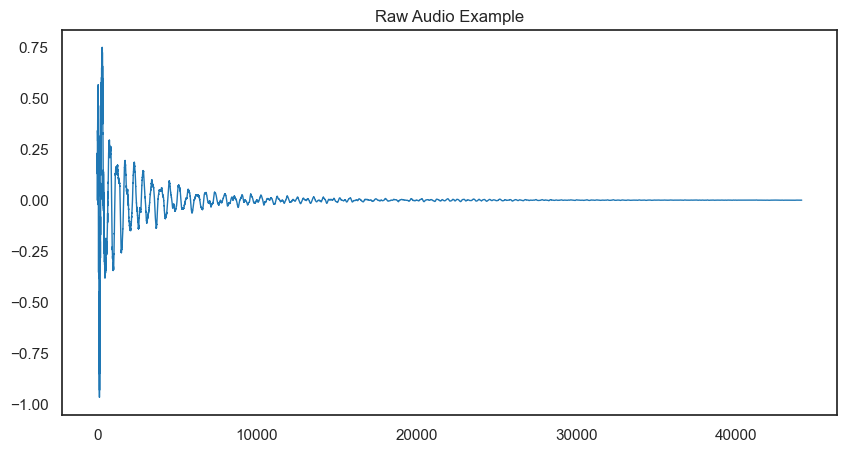

In [55]:
pd.Series(y).plot(figsize=(10, 5), lw=1, title="Raw Audio Example", color=color_pal[0])
plt.show()

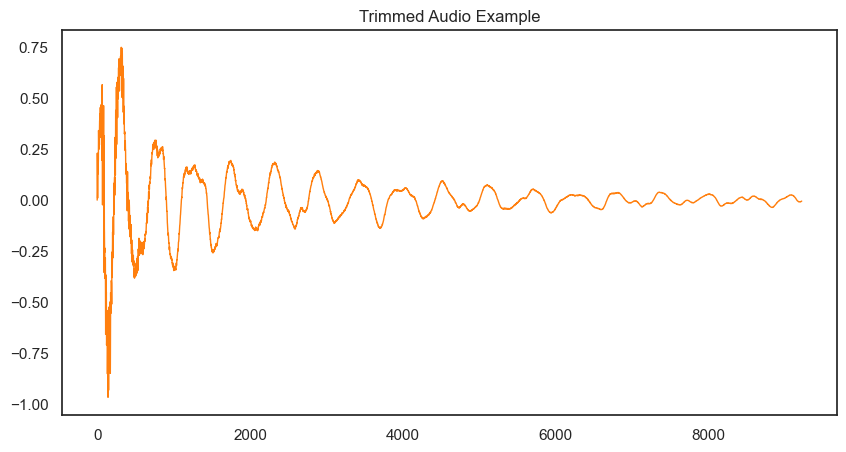

In [56]:
y_trimmed, _ = librosa.effects.trim(y, top_db=25)

pd.Series(y_trimmed).plot(figsize=(10, 5), lw=1, title="Trimmed Audio Example", color=color_pal[1])
plt.show()

In [57]:
# pd.Series(y[30000:30500]).plot(figsize=(10, 5), lw=1, title="Zoomed In Audio Example", color=color_pal[2])
# plt.show()

In [58]:
D = librosa.stft(y)
S_db = librosa.amplitude_to_db(np.abs(D), ref=np.max)
S_db.shape

(1025, 87)

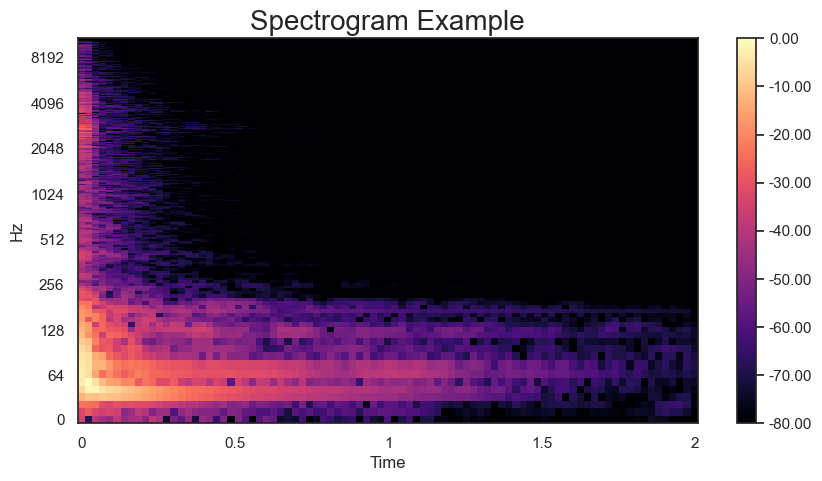

In [59]:
# Plot transformed audio data (this you can put into ML)
fig, ax = plt.subplots(figsize=(10, 5))
img = librosa.display.specshow(S_db,
                               x_axis='time',
                               y_axis='log',
                               ax=ax)
ax.set_title("Spectrogram Example", fontsize=20)
fig.colorbar(img, ax=ax, format=f'%0.2f')
plt.show()

In [60]:
# Mel Spectrogram
S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128 * 2, )
S_db_mel = librosa.amplitude_to_db(S, ref=np.max)

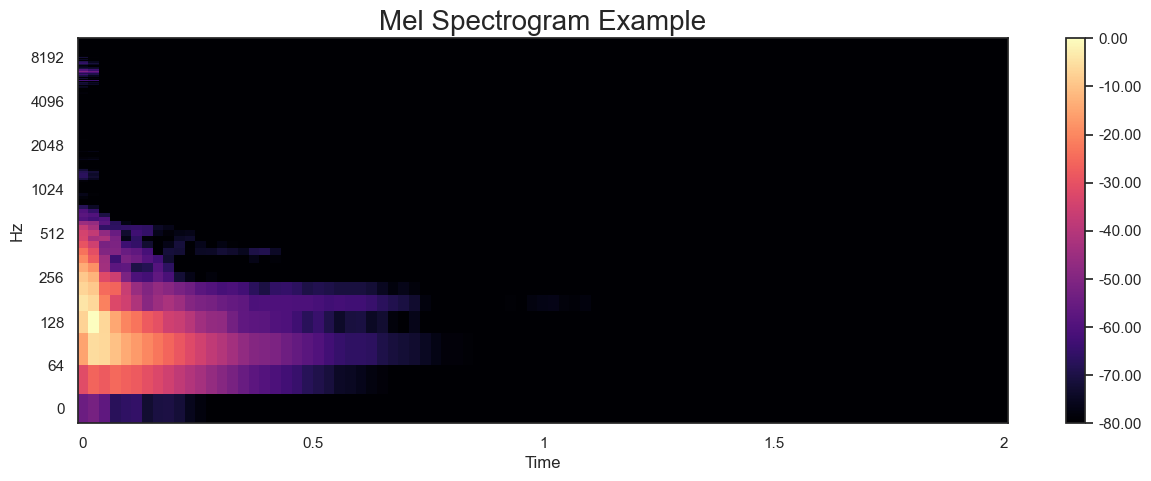

In [61]:
fig, ax = plt.subplots(figsize=(15, 5))
img = librosa.display.specshow(S_db_mel,
                               x_axis='time',
                               y_axis='log',
                               ax=ax)
ax.set_title("Mel Spectrogram Example", fontsize=20)
fig.colorbar(img, ax=ax, format=f'%0.2f')
plt.show()